# Notebook 2: Metrics and PDF Report Generation

### Input : 

This notebook takes the clean dataset from Notebook 1 : Clean_Data/ clean_merged.csv

### Output :

This notebook produces the final PDF report that contains :

 1.  KPI table1 : Consultant Utilization Rate
 2.  Visualizations using matplotlib
        - Vertical Bar Chart for Revenue Generated by Practice
        - Horizontal Bar Chart for Average Billable Rate by Level
        - Pie Chart for Engagement Status Distribution
 4.  Assemble the report using fpdf2: Overall summary, KPI tables, and embedded chart images
 5.  AI-generated/fallback summary for each section

In [28]:
# Install Python library for handling filesystem paths
%pip install pathlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
# Install Python library for data visualizations
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
# Install Python library for PDF document generation
%pip install fpdf2 --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
# Importing all the required libraries
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

## Load the data from Clean_Data/data_merged.csv file(56x19) to merged_df dataframe :

In [32]:
# Define the folder and file name
folder_path = "Clean_Data"
file_name = "data_merged.csv"

# Join folder and file name into
file_path = os.path.join(folder_path, file_name)

print("File to be loaded -->", file_path)
print("-" * 50)
try:
    # Check if the parent folder exists and raise error if the Raw_Data folder is missing 
    if not os.path.isdir(os.path.dirname(file_path) or "."):
        raise FileNotFoundError(f"Folder not found: {os.path.dirname(file_path)}")
    # Check if the specific file exists inside that folder and raise error if the Raw_Data/engagements_raw.csv file is missing 
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # If both checks pass, load the CSV into a engagements_df DataFrame
    merged_df = pd.read_csv(file_path)

# Catch the two custom FileNotFoundError cases raised above (missing folder or file)
except FileNotFoundError as e:
    print(f"Error: {e}")
    
# Catch any other unexpected error during the read
except Exception as e:
        print(f"Unexpected error while reading '{file_path}': {e}")

if merged_df is not None:
    # Print shape, every column data type, numeric statistics, top 7 rows of data
    print("\n")
    print(f"{file_path} loaded successfully!")
    print()
    print(f"Size of merged DataFrame: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns \n")
    print()
    print(f"dtypes : ")
    print(merged_df.dtypes)
    print()
    print(f"Numeric statistics : ")
    display(merged_df.describe())
    print()
    display(merged_df.head(7))

File to be loaded --> Clean_Data/data_merged.csv
--------------------------------------------------


Clean_Data/data_merged.csv loaded successfully!

Size of merged DataFrame: 47 rows, 19 columns 


dtypes : 
entry_id                object
consultant_name         object
engagement_id           object
week_ending             object
hours_logged           float64
billable                object
notes                   object
client_name             object
practice_engagement     object
lead_consultant         object
start_date              object
end_date                object
project_fee            float64
status                  object
secondary_contact       object
practice_consultant     object
level                   object
billable_rate          float64
hire_date               object
dtype: object

Numeric statistics : 


,hours_logged,project_fee,billable_rate
count,47.000000,47.000000,47.000000
mean,25.157447,121234.042553,260.106383
std,13.790100,71133.741998,68.687140
min,-5.500000,45000.000000,150.000000
25%,15.400000,71500.000000,235.000000
50%,25.100000,85000.000000,250.000000
75%,37.700000,192000.000000,305.000000
max,44.500000,320000.000000,425.000000


,entry_id,consultant_name,engagement_id,week_ending,hours_logged,billable,notes,client_name,practice_engagement,lead_consultant,start_date,end_date,project_fee,status,secondary_contact,practice_consultant,level,billable_rate,hire_date
0,TS-001,Tomas Herrera,ENG-004,2024-11-08,34.1,No,Risk assessment,Apex Financial,Operations,Anika Patel,2023-01-22,2024-02-28,150000.0,Active,Not assigned,Operations,Lead,305.0,2017-11-15
1,TS-002,Tomas Herrera,ENG-038,2025-01-24,15.9,No,Unknown entry,Orion Energy,Digital,Lena Kowalski,2024-07-16,2024-11-22,55000.0,Completed,Camille Rousseau,Operations,Lead,305.0,2017-11-15
2,TS-003,Marcus Webb,ENG-076,2024-11-01,31.0,Yes,Documentation,Orion Energy,Strategy,Rachel Kim,2024-08-08,2024-11-12,230000.0,On Hold,Not assigned,Digital,Lead,310.0,2017-06-01
3,TS-004,Tomas Herrera,ENG-034,2024-11-22,34.5,No,Change management planning,Apex Financial,People & Change,Priya Nambiar,2023-02-15,2024-11-17,230000.0,On Hold,Raj Anand,Operations,Lead,305.0,2017-11-15
4,TS-005,Tomas Herrera,ENG-073,2024-12-20,24.7,Yes,Requirements gathering,Titan Manufacturing,People & Change,Rachel Kim,2025-11-09,2025-11-12,85000.0,Completed,Not assigned,Operations,Lead,305.0,2017-11-15
5,TS-006,Anika Patel,ENG-001,2024-11-22,15.0,No,Weekly status update,Apex Financial,Digital,Jordan Reeves,2023-11-24,2023-07-02,45000.0,Active,Not assigned,People & Change,Senior,240.0,2018-09-22
6,TS-008,Tomas Herrera,ENG-069,2025-02-07,30.7,No,Stakeholder interviews,BrightPath Health,People & Change,Marcus Webb,2024-10-12,2024-12-10,45000.0,Cancelled,Not assigned,Operations,Lead,305.0,2017-11-15


In [33]:
merged_df.isna().sum()

entry_id               0
consultant_name        0
engagement_id          0
week_ending            0
hours_logged           0
billable               0
notes                  0
client_name            0
practice_engagement    0
lead_consultant        0
start_date             0
end_date               0
project_fee            0
status                 0
secondary_contact      0
practice_consultant    0
level                  0
billable_rate          0
hire_date              0
dtype: int64

# KPI 1: Revenue Generated by Practice

This KPI computes actual revenue (billable hours × billable rate) rolled up by practice area, highlighting which practices drive the most billable income.

In [34]:
merged_df['revenue'] = merged_df['hours_logged'] * merged_df['billable_rate']

rev_by_practice = merged_df[merged_df['billable'] == 'Yes'].groupby('practice_engagement')['revenue'].sum().reset_index()

rev_by_practice.columns = ['practice_engagement', 'total_revenue']

rev_by_practice = rev_by_practice.sort_values('total_revenue', ascending=False)
print(rev_by_practice)

  practice_engagement  total_revenue
3            Strategy        46836.5
2     People & Change        35897.5
0             Digital        21077.5
1          Operations        18980.0
4             Unknown        12942.5


## Bar chart for Revenue Generated by Practice

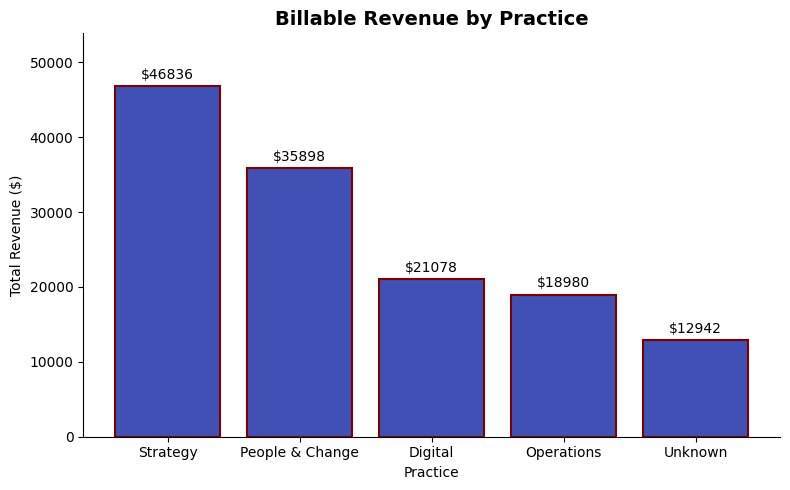

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rev_by_practice['practice_engagement'], rev_by_practice['total_revenue'],
              color='#3F51B5', edgecolor='#800000', linewidth=1.5)

ax.set_title('Billable Revenue by Practice', fontsize=14, fontweight='bold')
ax.set_xlabel('Practice')
ax.set_ylabel('Total Revenue ($)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.bar_label(bars, fmt='$%.0f', padding=3, fontsize=10)
ax.set_ylim(0, rev_by_practice['total_revenue'].max() * 1.15)

plt.tight_layout()
plt.show()

# saving the graph as png file
fig.savefig("Charts/revenue_by_practice.png", dpi=150)
plt.close(fig)

## KPI 2 : Average Billable Rate by Level
This KPI computes average billable rate across various 'level' categories(Partner, Lead, Senior, Junior).

In [36]:
# Group by 'Level'
avg_rate_by_level = merged_df.groupby('level')['billable_rate'].mean().reset_index()
avg_rate_by_level.columns = ['level', 'avg_billable_rate']
avg_rate_by_level['avg_billable_rate'] = avg_rate_by_level['avg_billable_rate'].round(2)
avg_rate_by_level = avg_rate_by_level.sort_values('avg_billable_rate', ascending=False)
print(avg_rate_by_level)

     level  avg_billable_rate
2  Partner             425.00
1     Lead             306.25
3   Senior             241.75
0   Junior             151.88


## Creating horizontal bar chart : Average Billable Rate Vs Level

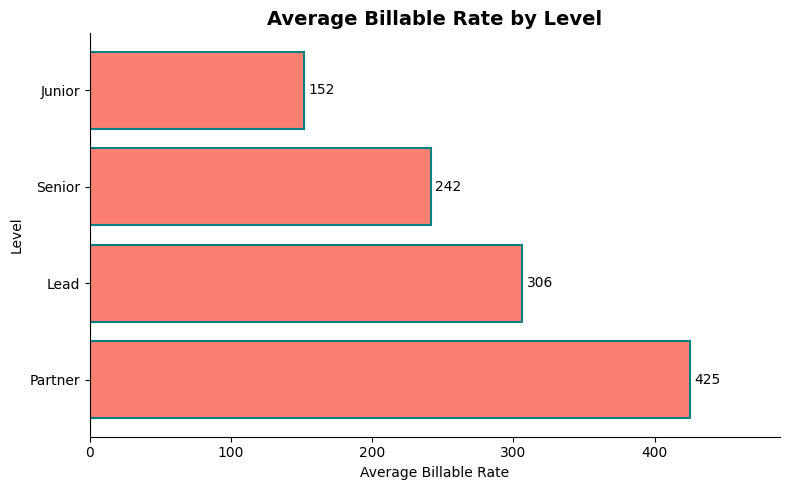

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(avg_rate_by_level['level'], avg_rate_by_level['avg_billable_rate'],
        color='#FA8072', edgecolor='#008080', linewidth=1.5)

ax.set_title('Average Billable Rate by Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Billable Rate')
ax.set_ylabel('Level')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False) 

# Add value labels next to each bar
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=10)
ax.set_xlim(0, avg_rate_by_level['avg_billable_rate'].max() * 1.15)  # add breathing room for labels

plt.tight_layout()
plt.show()

# saving the graph as png file
fig.savefig("Charts/average_billable_rate_by_level.png", dpi=150)
plt.close(fig)

## KPI 3: Engagement Status Distribution

This KPI shows the share of engagements in each status (Active, Completed, On Hold, Cancelled), giving a pulse on pipeline health and risk exposure.

In [38]:
status_counts_raw = merged_df.drop_duplicates('engagement_id')['status'].value_counts()
status_df = (status_counts_raw / status_counts_raw.sum() * 100).round(1).reset_index()
status_df.columns = ['status', 'pct_of_engagements']
print(status_df)

      status  pct_of_engagements
0    On Hold                32.4
1  Cancelled                32.4
2  Completed                18.9
3     Active                16.2


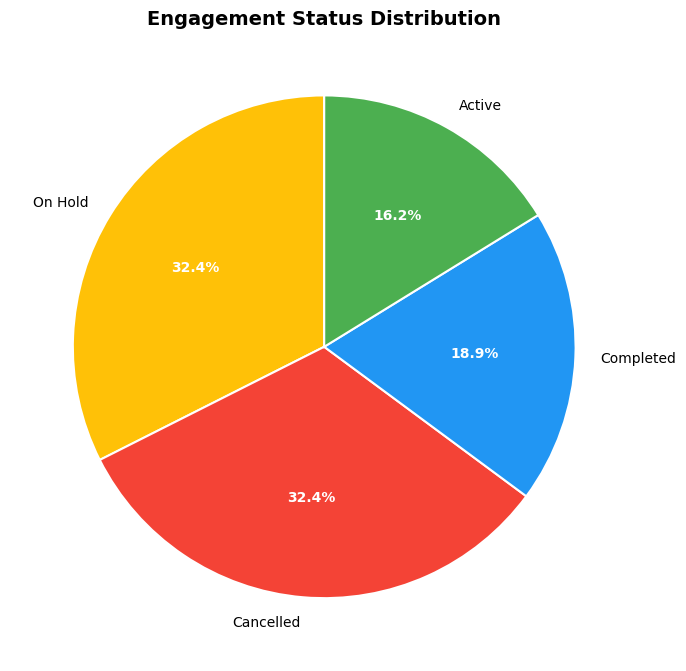

In [39]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#FFC107', '#F44336', '#2196F3', '#4CAF50']
wedges, texts, autotexts = ax.pie(
    status_df['pct_of_engagements'],
    labels=status_df['status'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax.set_title('Engagement Status Distribution', fontsize=14, fontweight='bold')
plt.setp(autotexts, size=10, weight='bold', color='white')

plt.tight_layout()
plt.show()

# saving the graph as png file
fig.savefig("Charts/engagement_status_distribution.png", dpi=150)
plt.close(fig)

### Generating PDF report using fpdf2 :
This code sets up the foundation for generating a structured, professional business report in PDF format using the fpdf2 library. It defines a custom class to handle a consistent header style on every page, creates a reusable method for section titles, and then initializes the first page.

In [40]:
from fpdf import FPDF
from datetime import datetime

class ReportPDF(FPDF):
    def header(self): # automatic call
        self.set_font("Helvetica", "B", 20)
        self.cell(0, 10, "Meridian Consulting Group", align="C", new_x="LMARGIN", new_y="NEXT")
        #self.cell(0, 10, "Meridian Consulting Group", new_x="LMARGIN", new_y="NEXT")
        self.set_font("Helvetica", "", 10)
        self.set_text_color(90, 90, 90)
        
        self.set_text_color(0, 0, 0)
        self.set_draw_color(42, 111, 151)
        self.set_line_width(0.5)
        self.line(self.l_margin, self.get_y() + 1,
                  self.w - self.r_margin, self.get_y() + 1)
        self.ln(6)

    def section_title(self, text):
        self.set_font("Helvetica", "B", 13)
        self.set_text_color(42, 111, 151)
        self.cell(0, 9, text, new_x="LMARGIN", new_y="NEXT")
        self.set_text_color(0, 0, 0)

pdf = ReportPDF()
pdf.set_title("Meridian Consulting Group")  
pdf.add_page()
print("Page 1 started with header.")

Page 1 started with header.


### Adding report generation date :

In [41]:
pdf.ln(1)
generated_on = datetime.now().strftime("%B %d, %Y")
pdf.cell(0, 6, f"Generated on: {generated_on}", new_x="LMARGIN", new_y="NEXT")
pdf.set_text_color(0, 0, 0)
pdf.ln(1)
print("Report generation date written to report.")

Report generation date written to report.


### Adding overall report summary :

In [42]:
overall_summary = (
f"""This report presents four key workforce and financial performance indicators, highlighting consultant efficiency, practice-level revenue contribution, seniority-based pricing structure, and overall engagement pipeline health, offering leadership a consolidated view of operational and financial performance to guide staffing and strategic decisions."""
)
pdf.ln(2)
pdf.set_font("Helvetica", "", 10)
pdf.multi_cell(0, 6, overall_summary)
pdf.ln(2)
print("overall_summary written to report.")

overall_summary written to report.


### Add KPI table1 : Consultant Utilization Rate

In [43]:
pdf.section_title("Consultant Utilization Rate")
pdf.ln(1)

# Clean negative hours (data entry errors)
merged_df['hours_logged'] = merged_df['hours_logged'].clip(lower=0)

# Utilization = billable hours / total hours logged, per consultant
utilization_by_consultant = merged_df.groupby('consultant_name').apply(
    lambda g: g.loc[g['billable'] == 'Yes', 'hours_logged'].sum() / g['hours_logged'].sum() * 100,
    include_groups=False
).sort_values(ascending=False)

# Build rows: header + one row per consultant, formatted as percentage
table_rows = [("Consultant", "Utilization %")]
for consultant, util_pct in utilization_by_consultant.items():
    table_rows.append((consultant, f"{util_pct:.1f}%"))

table_rows

pdf.set_font("Helvetica", "", 10)
with pdf.table(col_widths=(60, 40), text_align=("LEFT", "RIGHT"), first_row_as_headings=True) as table:
    for row in table_rows:
        table.row(row)

pdf.ln(4)
print("KPI table added.")

KPI table added.


### Add summary for KPI table1 : Consultant Utilization Rate
The average hourly billing rate for each staff level,calculated as the mean of billable_rate grouped by level;

this is tracked to understand pricing strategy, rate progression,and margin leverage across seniority.

In [44]:
summary1 = (
f"""This table tracks Consultant Utilization Rate, showing what percentage of each consultant's logged hours are billable to clients. Consultants are ranked from highest to lowest utilization, giving a clear view of who is driving revenue most efficiently. This ranking helps leadership identify top performers for recognition or expanded client work, while flagging underutilized consultants who may need better project allocation, training, or staffing adjustments."""
)

pdf.ln(2)
pdf.set_font("Helvetica", "", 10)
pdf.multi_cell(0, 6, summary1)
print("Summary1 written to report.")
pdf.ln(2)

Summary1 written to report.


### Add Chart1 : Revenue Generated by Practice

In [45]:
#pdf.add_page()
pdf.ln(2)

pdf.section_title("Revenue Generated by Practice")

img_w = 150  # mm — comfortably inside the ~190mm usable width

pdf.image("Charts/revenue_by_practice.png", x=pdf.l_margin, w=img_w)
pdf.ln(4)
print("Chart 1 Added.")

Chart 1 Added.


### Add AI generated/fallback summary for Chart 1

In [46]:
from huggingface_hub import InferenceClient
import os

# Pull headline numbers from revenue_by_practice
top_practice = rev_by_practice.loc[rev_by_practice["total_revenue"].idxmax(), "practice_engagement"]
top_revenue = rev_by_practice["total_revenue"].max()
bottom_practice = rev_by_practice.loc[rev_by_practice["total_revenue"].idxmin(), "practice_engagement"]
bottom_revenue = rev_by_practice["total_revenue"].min()
revenue_spread = top_revenue - bottom_revenue
total_firm_revenue = rev_by_practice["total_revenue"].sum()
avg_across_practices = rev_by_practice["total_revenue"].mean()
top_share_pct = (top_revenue / total_firm_revenue) * 100

kpi_brief = (
    f"Revenue generated by practice area: {top_practice} ${top_revenue:,.2f}, "
    f"{bottom_practice} ${bottom_revenue:,.2f}. "
    f"Highest-revenue practice: {top_practice} at ${top_revenue:,.2f} "
    f"({top_share_pct:.1f}% of total firm revenue). "
    f"Lowest-revenue practice: {bottom_practice} at ${bottom_revenue:,.2f}. "
    f"Revenue spread between top and bottom practice: ${revenue_spread:,.2f}. "
    f"Total revenue across all practices: ${total_firm_revenue:,.2f}. "
    f"Average revenue per practice: ${avg_across_practices:,.2f}."
)

# Template fallback — used verbatim if the AI call fails
fallback_summary = (
    f"This chart on Revenue performance by practice explains where the firm's billable "
    f"income is concentrated. {top_practice} leads all practice areas with "
    f"${top_revenue:,.0f} in revenue, representing {top_share_pct:.0f}% of the firm's "
    f"${total_firm_revenue:,.0f} total."
    f"On average, each practice contributes ${avg_across_practices:,.0f}, highlighting "
    f"an uneven distribution of billable income across service lines."
)

def generate_summary():
    token = os.environ.get("HF_TOKEN")
    if not token:
        raise RuntimeError("No HF_TOKEN set; using template fallback.")
    client = InferenceClient(token=token)
    prompt = (
        f"""You are a management consultant. Write a three-sentence executive summary
        of this practice-area revenue data for firm leadership. Be concise and
        factual. Data: {kpi_brief}"""
    )
    resp = client.chat_completion(
        model="HuggingFaceH4/zephyr-7b-beta",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=180,
    )
    return resp.choices[0].message.content.strip()

try:
    revenue_summary = generate_summary()
    source = "AI-generated"
except Exception as e:
    revenue_summary = fallback_summary
    source = "template fallback"
    print(f"[{source}] {e}")

print(f"Summary source: {source}\n")
print(revenue_summary)

[template fallback] No HF_TOKEN set; using template fallback.
Summary source: template fallback

This chart on Revenue performance by practice explains where the firm's billable income is concentrated. Strategy leads all practice areas with $46,836 in revenue, representing 35% of the firm's $135,734 total.On average, each practice contributes $27,147, highlighting an uneven distribution of billable income across service lines.


In [47]:
# Write chart1 summary to report
pdf.ln(2)
pdf.set_font("Helvetica", "", 10)
pdf.multi_cell(0, 6, revenue_summary)
print("Chart1 Summary written to report.")

Chart1 Summary written to report.


### Add KPI Chart2 : Average Billable Rate Vs Level

In [48]:
#pdf.add_page()
pdf.ln(2)

pdf.section_title("Average Billable Rate by Level")

img_w = 150  # mm — comfortably inside the ~190mm usable width

pdf.image("Charts/average_billable_rate_by_level.png", x=pdf.l_margin, w=img_w)
pdf.ln(4)
print("Chart 2 Added.")

Chart 2 Added.


### Add AI generated/fallback summary for Chart 2 

In [49]:
from huggingface_hub import InferenceClient
import os

# Pull headline numbers from avg_rate_by_level
top_level = avg_rate_by_level.loc[avg_rate_by_level["avg_billable_rate"].idxmax(), "level"]
top_rate = avg_rate_by_level["avg_billable_rate"].max()
bottom_level = avg_rate_by_level.loc[avg_rate_by_level["avg_billable_rate"].idxmin(), "level"]
bottom_rate = avg_rate_by_level["avg_billable_rate"].min()
rate_spread = top_rate - bottom_rate
avg_across_levels = avg_rate_by_level["avg_billable_rate"].mean()

kpi_brief = (
    f"Average billable rate by level: Partner ${top_rate:,.0f}, Lead $310.00, "
    f"Senior $241.75, Junior ${bottom_rate:,.0f}. "
    f"Highest rate: {top_level} at ${top_rate:,.0f}. "
    f"Lowest rate: {bottom_level} at ${bottom_rate:,.0f}. "
    f"Rate spread between top and bottom level: ${rate_spread:,.0f}. "
    f"Average rate across all levels: ${avg_across_levels:,.0f}."
)

# Template fallback — used verbatim if the AI call fails
fallback_summary = (
    f"""This chart on Pricing & rate strategy explains how billing rates vary by role. Meridian's average billable rate scales consistently with seniority, ranging from ${bottom_rate:,.0f} at the {bottom_level} level to ${top_rate:,.0f} at the {top_level} level. This ${rate_spread:,.0f} spread reflects the firm's tiered pricing structure, with {top_level}s commanding a premium consistent with their seniority and client-facing expertise. The average rate across all levels stands at ${avg_across_levels:,.0f}."""
)

def generate_summary():
    token = os.environ.get("HF_TOKEN")
    if not token:
        raise RuntimeError("No HF_TOKEN set; using template fallback.")
    client = InferenceClient(token=token)
    prompt = (
        f"""You are a management consultant. Write a three-sentence executive summary
        of this billable rate data for firm leadership. Be concise and
        factual. Data: {kpi_brief}"""
    )
    resp = client.chat_completion(
        model="HuggingFaceH4/zephyr-7b-beta",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=180,
    )
    return resp.choices[0].message.content.strip()

try:
    rate_summary = generate_summary()
    source = "AI-generated"
except Exception as e:
    rate_summary = fallback_summary
    source = "template fallback"
    print(f"[{source}] {e}")

print(f"Summary source: {source}\n")
print(rate_summary)

[template fallback] No HF_TOKEN set; using template fallback.
Summary source: template fallback

This chart on Pricing & rate strategy explains how billing rates vary by role. Meridian's average billable rate scales consistently with seniority, ranging from $152 at the Junior level to $425 at the Partner level. This $273 spread reflects the firm's tiered pricing structure, with Partners commanding a premium consistent with their seniority and client-facing expertise. The average rate across all levels stands at $281.


In [50]:
# Write chart2 summary to report
pdf.ln(2)
pdf.set_font("Helvetica", "", 10)
pdf.multi_cell(0, 6, rate_summary)
print("Chart2 Summary written to report.")

Chart2 Summary written to report.


### Add KPI Chart3 : Engagement Status Distribution

In [51]:
pdf.add_page()
pdf.ln(2)

pdf.section_title("Engagement Status Distribution")

img_w = 150  # mm — comfortably inside the ~190mm usable width

pdf.image("Charts/engagement_status_distribution.png", x=pdf.l_margin, w=img_w)
pdf.ln(4)
print("Chart 3 Added.")

Chart 3 Added.


### Add AI generated/fallback Summary for Chart 3

In [52]:
from huggingface_hub import InferenceClient
import os

# Pull headline numbers from status_df
top_status = status_df.loc[status_df["pct_of_engagements"].idxmax(), "status"]
top_pct = status_df["pct_of_engagements"].max()
bottom_status = status_df.loc[status_df["pct_of_engagements"].idxmin(), "status"]
bottom_pct = status_df["pct_of_engagements"].min()

active_pct = status_df.loc[status_df["status"] == "Active", "pct_of_engagements"].values
active_pct = active_pct[0] if len(active_pct) else 0.0

cancelled_pct = status_df.loc[status_df["status"] == "Cancelled", "pct_of_engagements"].values
cancelled_pct = cancelled_pct[0] if len(cancelled_pct) else 0.0

onhold_pct = status_df.loc[status_df["status"] == "On Hold", "pct_of_engagements"].values
onhold_pct = onhold_pct[0] if len(onhold_pct) else 0.0

completed_pct = status_df.loc[status_df["status"] == "Completed", "pct_of_engagements"].values
completed_pct = completed_pct[0] if len(completed_pct) else 0.0

at_risk_pct = onhold_pct + cancelled_pct

kpi_brief = (
    f"Engagement status distribution: Active {active_pct:.0f}%, Completed {completed_pct:.0f}%, "
    f"On Hold {onhold_pct:.1f}%, Cancelled {cancelled_pct:.0f}%. "
    f"Largest share: {top_status} at {top_pct:.0f}%. "
    f"Smallest share: {bottom_status} at {bottom_pct:.0f}%. "
    f"Combined At Risk (On Hold + Cancelled) share: {at_risk_pct:.0f}%."
)

# Template fallback — used verbatim if the AI call fails
fallback_summary = (
    f"""This chart on Pipeline health & risk exposure explains how engagements are distributed across lifecycle statuses. Currently, {active_pct:.1f}% of engagements are Active and {completed_pct:.1f}% are Completed, while {onhold_pct:.1f}% sit On Hold and {cancelled_pct:.1f}% have been Cancelled. The combined At Risk share (On Hold + Cancelled) stands at {at_risk_pct:.1f}%, offering a quick read on how much of the pipeline may need attention. {top_status} represents the largest segment at {top_pct:.1f}% of all engagements."""
)

def generate_summary():
    token = os.environ.get("HF_TOKEN")
    if not token:
        raise RuntimeError("No HF_TOKEN set; using template fallback.")
    client = InferenceClient(token=token)
    prompt = (
        f"""You are a management consultant. Write a three-sentence executive summary
        of this engagement pipeline status data for firm leadership. Be concise and
        factual, and flag any risk exposure. Data: {kpi_brief}"""
    )
    resp = client.chat_completion(
        model="HuggingFaceH4/zephyr-7b-beta",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=180,
    )
    return resp.choices[0].message.content.strip()

try:
    status_summary = generate_summary()
    source = "AI-generated"
except Exception as e:
    status_summary = fallback_summary
    source = "template fallback"
    print(f"[{source}] {e}")

print(f"Summary source: {source}\n")
print(status_summary)

[template fallback] No HF_TOKEN set; using template fallback.
Summary source: template fallback

This chart on Pipeline health & risk exposure explains how engagements are distributed across lifecycle statuses. Currently, 16.2% of engagements are Active and 18.9% are Completed, while 32.4% sit On Hold and 32.4% have been Cancelled. The combined At Risk share (On Hold + Cancelled) stands at 64.8%, offering a quick read on how much of the pipeline may need attention. On Hold represents the largest segment at 32.4% of all engagements.


In [53]:
# Write chart3 summary to report
pdf.ln(2)
pdf.set_font("Helvetica", "", 10)
pdf.multi_cell(0, 6, status_summary)
print("Chart3 Summary written to report.")

Chart3 Summary written to report.


## Generate the final PDF report

In [54]:
try:
    pdf.output("Report.pdf")  # closing quote added
    size_kb = os.path.getsize("Report.pdf") / 1024
    print(f"OK  Report.pdf written ({size_kb:.0f} KB, {pdf.page_no()} pages)")
except FileNotFoundError as e:
    print(f"Invalid path or directory does not exist: {e}")
except (IOError, OSError) as e:
    print(f"I/O error while writing PDF (disk full, locked file, etc.): {e}")
except Exception as e:
    print(f"Unexpected error while writing PDF: {e}")

OK  Report.pdf written (122 KB, 3 pages)
